# Feishu Quant Competition - Production Strategy

## Signal in one line
```
alpha = 0.8 * z(BaseAlpha_res_l5) + 0.2 * z(ridge_5d)
```
where `BaseAlpha_res_l5` is an 8-factor ICIR-weighted blend with sector-mean partially removed, and `ridge_5d` is a walk-forward Ridge regression on the 5-day forward rank. Portfolio: concentrated (N=12) inverse-vol/alpha-rank blend, sector-residualised, vol-targeted with a breadth gross-up overlay, sell-at-open.


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
DAILY_PATH = ROOT/'daily_data_in_sample.parquet'
LOB_PATH   = ROOT/'lob_data_in_sample.parquet'

# ===================== PRODUCTION CONFIG =====================
# All hyperparameters below were selected using in-sample analysis and fixed before out-of-sample evaluation.

# Portfolio construction
USE_AGGRESSIVE_CONC = True       # concentrated book
CONC_N_TARGET       = 12        # target holdings: IS-selected balance of diversification, stability and signal concentration
CONC_NAME_CAP       = 0.09        # per-name cap: bounds single-name gap risk in a concentrated book
CONC_MIN_HOLDINGS   = 10
USE_ALPHA_RANK_SIZE = True       # weights = 0.5*inv_vol + 0.5*alpha_rank
ALPHA_RANK_BLEND    = 0.50
STICKY_TOP_K        = 50
REBAL_EVERY         = 10
AMT_MIN             = 300_000.0

# Alpha
USE_SECTOR_RESID    = True
SECTOR_RESID_LAMBDA = 0.50        # partial sector-mean removal
N_CLUSTERS_SEC      = 10
ENS_RIDGE_W         = 0.20        # weight on the ridge-5d signal in the ensemble (20% chosen on IS: enough to add decorrelated ML signal without destabilising the base)
RIDGE_ALPHA_REG     = 10.0
RIDGE_HORIZON       = 5
ML_RETRAIN          = 30        # Ridge retrain interval (days): adapts to drift while staying stable/cheap
ML_PURGE            = 12        # purge gap (days) > RIDGE_HORIZON so no training label overlaps the prediction day (anti-leakage)

# Risk overlay
VOL_TARGET_ANN   = 0.18        # annual vol target: IS-calibrated, trades CAGR against the drawdown score term
VOL_SCALE_LOW    = 0.90
VOL_SCALE_HIGH   = 1.10
USE_BREADTH_GROSSUP = True
BREADTH_HI       = 0.55
BREADTH_GROSS_HI = 1.20
DD_BREAKER       = -0.05        # drawdown breaker: cut gross when >5% below peak to defend the MaxDD score term
DD_COOL_DAYS     = 3
GROSS_FLOOR_DD   = 0.50

# Execution (rule-bound)
SELL_MODE   = 'open'      
INITIAL_CAPITAL = 50_000_000.0
FEE_BPS_BUY = 1e-4; FEE_BPS_SELL = 6e-4; MIN_FEE = 5.0
LOT = 100; WARMUP_DAY = 80; TRADING_DAYS_YR = 252; ML_HORIZON = 10

DAILY_FACTORS = ['REV_1','REV_3','REV_5','REV_10','REV_20','MOM_60_20','LOWVOL','ILLIQ',
                 'OVNT','MORN_REV','INTRA_MOM','RANGE_PCT','CLOSE_STRENGTH','RANGE_TREND','SKEW_60','AMT_GROWTH_5']
LOB_OLD = ['OFI_D','DWI_D','SPR_D','DWI10_D','OFI_LAST4','OFI_TREND']
LOB_NEW = ['OFI_RANGE','MIDPRICE_VOL','BOOK_TIGHTNESS','DWI_AFT_MORN','SPR_RANGE']
LOB_FACTORS = LOB_OLD + LOB_NEW
ALL_FACTORS = DAILY_FACTORS + LOB_FACTORS
print('production config loaded.')

production config loaded.


### Leakage control

Look-ahead is removed at the source, and every fitted artifact is in-sample only:
- **1-day factor lag** - each factor is `shift(1)`, so a day-*t* decision uses only data through the close of *t*-1.
- **IS-only factor weights** - the IC-IR blend is fit on in-sample data with the forward-return target masked at the IS boundary.
- **Frozen sectors** - the PCA+KMeans sector map is estimated once on D080-D240 and reused unchanged thereafter (no OOS refit).
- **Purged walk-forward ML** - the Ridge trains only on past data with a 12-day purge that exceeds the 5-day target horizon.

## 1. Load daily data

In [2]:
daily = pl.read_parquet(DAILY_PATH).sort(['asset_id','trade_day_id'])
print('rows', daily.height, '| days', daily['trade_day_id'].n_unique(), '| assets', daily['asset_id'].n_unique())

rows 1060121 | days 484 | assets 2270


## 2. Daily factors

In [3]:
d = daily.with_columns([(pl.col('close')*pl.col('adj_factor')).alias('adj_close')])
d = d.with_columns([pl.col('adj_close').pct_change().over('asset_id').alias('ret_d'),
                    pl.col('amount').rolling_median(window_size=20,min_samples=10).over('asset_id').alias('amt_med20')])
d = d.with_columns([(pl.col('ret_d').abs()/pl.col('amount').clip(lower_bound=1.0)).alias('illiq_d'), pl.col('volume').log1p().alias('log_vol')])
d = d.with_columns([(-(pl.col('adj_close')/pl.col('adj_close').shift(1).over('asset_id')-1.0)).alias('REV_1'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(3).over('asset_id')-1.0)).alias('REV_3'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(5).over('asset_id')-1.0)).alias('REV_5'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(10).over('asset_id')-1.0)).alias('REV_10'),
                    (-(pl.col('adj_close')/pl.col('adj_close').shift(20).over('asset_id')-1.0)).alias('REV_20')])
d = d.with_columns([(pl.col('adj_close').shift(20).over('asset_id')/pl.col('adj_close').shift(60).over('asset_id')-1.0).alias('MOM_60_20'),
                    (-pl.col('ret_d').rolling_std(window_size=20,min_samples=15).over('asset_id')).alias('LOWVOL'),
                    (-pl.col('illiq_d').rolling_mean(window_size=20,min_samples=15).over('asset_id')).alias('ILLIQ')])
d = d.with_columns([(-(pl.col('open')/pl.col('close').shift(1).over('asset_id')-1.0)).alias('OVNT'),
                    (-(pl.col('vwap_0930_0935')/pl.col('open').clip(lower_bound=1e-6)-1.0)).alias('MORN_REV'),
                    (pl.col('close')/pl.col('vwap_0930_0935').clip(lower_bound=1e-6)-1.0).alias('INTRA_MOM')])
d = d.with_columns([(-((pl.col('high')-pl.col('low'))/pl.col('close').clip(lower_bound=1e-6))).alias('RANGE_PCT'),
                    (-((pl.col('close')-pl.col('low'))/(pl.col('high')-pl.col('low')).clip(lower_bound=1e-6))).alias('CLOSE_STRENGTH')])
d = d.with_columns([pl.col('RANGE_PCT').rolling_mean(window_size=5,min_samples=3).over('asset_id').alias('_r5'),
                    pl.col('RANGE_PCT').rolling_mean(window_size=20,min_samples=10).over('asset_id').alias('_r20')])
d = d.with_columns([(pl.col('_r5')-pl.col('_r20')).alias('RANGE_TREND')]).drop(['_r5','_r20'])
d = d.with_columns([pl.col('ret_d').rolling_mean(window_size=60,min_samples=30).over('asset_id').alias('_mu60'),
                    pl.col('ret_d').rolling_std(window_size=60,min_samples=30).over('asset_id').alias('_sd60')])
d = d.with_columns([((pl.col('ret_d')-pl.col('_mu60'))**3).rolling_mean(window_size=60,min_samples=30).over('asset_id').alias('_m3')])
d = d.with_columns([(-(pl.col('_m3')/(pl.col('_sd60')**3).clip(lower_bound=1e-12))).alias('SKEW_60'),
                    (pl.col('amount')/pl.col('amount').shift(5).over('asset_id').clip(lower_bound=1.0)-1.0).alias('AMT_GROWTH_5')]).drop(['_mu60','_sd60','_m3'])
d = d.with_columns([((pl.col('close')/pl.col('close').shift(1).over('asset_id')-1.0)>0.095).alias('limit_up_prev'),
                    ((pl.col('volume')<=0)|(pl.col('volume').shift(1).over('asset_id')<=0)|(pl.col('volume').shift(2).over('asset_id')<=0)).alias('suspended_recent')])
print('daily factors done')

daily factors done


## 3. LOB factors - computed in-memory from the 10-min book

The 11 daily LOB factors are aggregated directly from the 10-minute, 10-level snapshots in
`lob_data_in_sample.parquet`

In [4]:
# LOB daily factors: computed in-memory directly from the 10-min order-book
if not LOB_PATH.exists():
    raise FileNotFoundError(f'{LOB_PATH.name} missing')

def dwi_expr(n_levels):
    parts = []
    for k in range(1, n_levels + 1):
        parts.append((1.0/k)*(pl.col(f'bid_volume_{k}')-pl.col(f'ask_volume_{k}'))/
                     (pl.col(f'bid_volume_{k}')+pl.col(f'ask_volume_{k}')).clip(lower_bound=1.0))
    return pl.sum_horizontal(parts)

# Aggregate the 10-min, 10-level book to one row per (asset, day) using the identical formulas
# the daily-LOB cache was previously built from (snap_idx = intraday slot 1..24).
lob_q = (
    pl.scan_parquet(LOB_PATH)
      .sort(['asset_id','trade_day_id','time'])
      .with_columns([
          pl.col('asset_id').cum_count().over(['asset_id','trade_day_id']).alias('snap_idx'),
          ((pl.col('bid_volume_1')-pl.col('ask_volume_1'))/(pl.col('bid_volume_1')+pl.col('ask_volume_1')).clip(lower_bound=1.0)).alias('ofi_s'),
          dwi_expr(5).alias('dwi5_raw'),
          dwi_expr(10).alias('dwi10_raw'),
          (((pl.col('ask_price_1')-pl.col('bid_price_1'))/((pl.col('ask_price_1')+pl.col('bid_price_1'))*0.5).clip(lower_bound=1e-6))).alias('spr_s'),
          ((pl.col('ask_price_1')+pl.col('bid_price_1'))*0.5).alias('mid_s'),
          ((pl.col('ask_price_5')-pl.col('bid_price_5'))/(pl.col('ask_price_1')-pl.col('bid_price_1')).clip(lower_bound=1e-6)).alias('tight_s'),
      ])
      .group_by(['asset_id','trade_day_id'])
      .agg([
          pl.col('ofi_s').mean().alias('OFI_D'),
          pl.col('dwi5_raw').mean().alias('DWI_D'),
          pl.col('dwi10_raw').mean().alias('DWI10_D'),
          (-pl.col('spr_s').mean()).alias('SPR_D'),
          pl.col('ofi_s').filter(pl.col('snap_idx')<=4).mean().alias('OFI_FIRST4'),
          pl.col('ofi_s').filter(pl.col('snap_idx')>=21).mean().alias('OFI_LAST4'),
          (pl.col('ofi_s').max()-pl.col('ofi_s').min()).alias('OFI_RANGE'),
          (pl.col('mid_s').std()/pl.col('mid_s').mean().clip(lower_bound=1e-6)).alias('MIDPRICE_VOL'),
          pl.col('tight_s').mean().alias('BOOK_TIGHTNESS'),
          (pl.col('dwi5_raw').filter(pl.col('snap_idx')>12).mean()
           - pl.col('dwi5_raw').filter(pl.col('snap_idx')<=12).mean()).alias('DWI_AFT_MORN'),
          (pl.col('spr_s').max()-pl.col('spr_s').min()).alias('SPR_RANGE'),
      ])
      .with_columns([(pl.col('OFI_LAST4')-pl.col('OFI_FIRST4')).alias('OFI_TREND')])
)
try:
    lob_daily = lob_q.collect(engine='streaming')
except Exception as e:
    print(f'streaming failed ({e}); falling back to in-memory collect')
    lob_daily = lob_q.collect()
print('built LOB daily factors:', lob_daily.height, 'rows,', len(lob_daily.columns), 'cols')

built LOB daily factors: 1061536 rows, 14 cols


## 4. Merge, lag 1 day, EMA-smooth LOB, cross-sectional z-score

In [5]:
drop_cols=[c for c in ['OFI_FIRST4'] if c in lob_daily.columns]
features = d.join(lob_daily.drop(drop_cols) if drop_cols else lob_daily, on=['asset_id','trade_day_id'], how='left')
# --- Leakage control: lag every factor by one trading day (shift(1)) ---
# A day-t decision may use information only through the close of t-1; lagging every
# factor enforces this causal boundary and removes look-ahead (forward-information) bias.
features = features.with_columns([pl.col(c).shift(1).over('asset_id').alias(c) for c in ALL_FACTORS])
# EMA-smooth the LOB factors (half-life 3 days)
ae = 1 - 0.5**(1/3)
features = features.with_columns([pl.col(c).ewm_mean(alpha=ae, adjust=False).over('asset_id').alias(c) for c in LOB_FACTORS])
def cs_z(col):
    q01=pl.col(col).quantile(0.01).over('trade_day_id'); q99=pl.col(col).quantile(0.99).over('trade_day_id')
    cl=pl.min_horizontal(pl.max_horizontal(pl.col(col),q01),q99); mu=cl.mean().over('trade_day_id'); sd=cl.std().over('trade_day_id')
    return ((cl-mu)/sd.clip(lower_bound=1e-9)).alias(f'z_{col}')
features = features.with_columns([cs_z(c) for c in ALL_FACTORS])
fdf = features.to_pandas().sort_values(['asset_id','trade_day_id']).reset_index(drop=True)
fdf['day_idx'] = fdf['trade_day_id'].str.slice(1).astype(int)
for h in [RIDGE_HORIZON, ML_HORIZON]:
    fdf[f'fwd_ret{h}']  = fdf.groupby('asset_id')['adj_close'].shift(-h)/fdf['adj_close'] - 1.0
    fdf[f'fwd_rank{h}'] = fdf.groupby('trade_day_id')[f'fwd_ret{h}'].rank(pct=True)
fdf['fwd_rank'] = fdf[f'fwd_rank{ML_HORIZON}']
print('feature frame:', fdf.shape)

feature frame: (1060121, 77)


## 5. `BaseAlpha` - 8-factor ICIR-weighted, family-diversified blend

Factors are vetted on loose gates (|IC|>=0.010, sign-stable across IS halves, |ICIR|>=0.12, corr-to-anchor<=0.65, coverage>=0.70), then the top-8 across distinct families are weighted by `sign(IC) * |ICIR| / sum|ICIR|`.

In [6]:
ANCHOR=['z_LOWVOL','z_SPR_D','z_DWI_D','z_REV_5']; LI,LH,LIC,LC=0.010,0.20,0.12,0.65
FAMILY={'z_REV_1':'rev','z_REV_3':'rev','z_REV_5':'rev','z_REV_10':'rev','z_REV_20':'rev','z_OVNT':'intra','z_MORN_REV':'intra','z_INTRA_MOM':'intra','z_RANGE_PCT':'range','z_CLOSE_STRENGTH':'range','z_RANGE_TREND':'range','z_OFI_D':'lob','z_DWI_D':'lob','z_SPR_D':'lob','z_DWI10_D':'lob','z_OFI_LAST4':'lob','z_OFI_TREND':'lob','z_OFI_RANGE':'lob2','z_MIDPRICE_VOL':'mvol','z_BOOK_TIGHTNESS':'btight','z_DWI_AFT_MORN':'lob2','z_SPR_RANGE':'srange','z_LOWVOL':'risk','z_ILLIQ':'risk','z_MOM_60_20':'trend','z_SKEW_60':'moments','z_AMT_GROWTH_5':'flow'}
def dic(col,sub=None,tgt='fwd_rank'):
    df=sub if sub is not None else fdf; w=df[[col,tgt,'trade_day_id']].dropna(subset=[col,tgt])
    if w.empty: return pd.Series(dtype=float)
    return w.groupby('trade_day_id',sort=False).apply(lambda x:x[col].corr(x[tgt],method='spearman') if len(x)>=10 else np.nan).dropna()
def icw(col,lo,hi):
    s=dic(col,fdf[(fdf['day_idx']>=lo)&(fdf['day_idx']<=hi)]); return s.mean() if len(s)>0 else np.nan
def fcorr(a,b):
    s=fdf[['trade_day_id',a,b]].dropna()
    if s.empty: return np.nan
    return s.groupby('trade_day_id',sort=False).apply(lambda x:x[a].corr(x[b],method='spearman') if len(x)>=20 else np.nan).dropna().mean()
def blend(cl,mx=8):
    rows=[]
    for c in cl:
        s=dic(c); icf=s.mean() if len(s)>0 else np.nan; ist=s.std() if len(s)>0 else np.nan
        icir=icf/(ist+1e-9) if not pd.isna(icf) else np.nan; h1=icw(c,80,280); h2=icw(c,281,484)
        ss=(not pd.isna(h1)) and (not pd.isna(h2)) and (np.sign(h1)==np.sign(h2)); cov=fdf[c].notna().mean(); mcx=0.0
        for vf in ANCHOR:
            if vf==c: continue
            cc=fcorr(c,vf)
            if not pd.isna(cc): mcx=max(mcx,abs(cc))
        keep=bool((not pd.isna(icf) and abs(icf)>=LI) and (ss and not pd.isna(icf) and min(abs(h1),abs(h2))>=LH*abs(icf)) and (not pd.isna(icir) and abs(icir)>=LIC) and (mcx<=LC) and (cov>=0.70))
        rows.append({'factor':c,'IC_full':icf,'ICIR':icir,'keep':keep})
    sc=pd.DataFrame(rows); k=sc[sc['keep']].copy(); k['fam']=k['factor'].map(FAMILY).fillna('misc'); k['ai']=k['ICIR'].abs()
    k=k.sort_values('ai',ascending=False).reset_index(drop=True); picks,fc=[],{}
    for _,r in k.iterrows():
        if fc.get(r['fam'],0)>=2: continue
        picks.append(r); fc[r['fam']]=fc.get(r['fam'],0)+1
        if len(picks)>=mx: break
    kp=pd.DataFrame(picks); ti=kp['ICIR'].abs().sum()
    return {r['factor']:float(np.sign(r['IC_full'])*abs(r['ICIR'])/ti) for _,r in kp.iterrows()}
base_w = blend([f'z_{c}' for c in ALL_FACTORS], 8)
fdf['BaseAlpha'] = sum(w*fdf[f].fillna(0) for f,w in base_w.items())
print('BaseAlpha factor weights:')
for f,w in sorted(base_w.items(), key=lambda x:-abs(x[1])): print(f'  {f:>16s}  {w:+.3f}')
s=dic('BaseAlpha'); print(f'\nBaseAlpha IC={s.mean():+.4f}  ICIR={s.mean()/(s.std()+1e-9):+.3f}')

BaseAlpha factor weights:
          z_LOWVOL  +0.174
       z_RANGE_PCT  +0.156
         z_SKEW_60  +0.155
          z_REV_20  +0.141
    z_DWI_AFT_MORN  -0.118
           z_SPR_D  -0.109
          z_REV_10  +0.074
            z_OVNT  -0.073

BaseAlpha IC=+0.1026  ICIR=+0.674


## 6. Eligibility (liquid, tradable, not limit-up, not suspended)

In [7]:
fdf['eligible_buy']=(fdf['vwap_0930_0935'].notna()&(fdf['vwap_0930_0935']>0)&fdf['open'].notna()&(fdf['open']>0)&fdf['close'].notna()&(fdf['close']>0)&(fdf['amt_med20'].fillna(0)>=AMT_MIN)&(~fdf['limit_up_prev'].fillna(False))&(~fdf['suspended_recent'].fillna(True)))
fdf['vol20d']=fdf.groupby('asset_id')['ret_d'].rolling(20,min_periods=15).std().reset_index(0,drop=True)
asset_ret=fdf.pivot_table(index='day_idx',columns='asset_id',values='ret_d')
print('eligible fraction:', round(fdf['eligible_buy'].mean(),3))

eligible fraction: 0.112


## 7. Sector clustering (PCA-20 + KMeans-10 on D080-D240 returns)

In [8]:
# --- Frozen statistical sectors (fit on IS only, never refit on OOS) ---
# PCA(20)+KMeans(10) are estimated once on the D080-D240 training window; the resulting
# asset -> cluster map is frozen and reused unchanged for validation/OOS, so the labels
# carry no forward-looking information.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
mc=(asset_ret.index>=WARMUP_DAY)&(asset_ret.index<=240); R=asset_ret.loc[mc]; cov=R.notna().mean(axis=0)
ka=cov[cov>=0.80].index.tolist(); R=R[ka].fillna(0.0)
X=R.T.values; X=(X-X.mean(axis=1,keepdims=True))/(X.std(axis=1,keepdims=True)+1e-9)
ncp=min(20,X.shape[1]-1,X.shape[0]-1); Xp=PCA(n_components=ncp,random_state=42).fit_transform(X)
km=KMeans(n_clusters=N_CLUSTERS_SEC,n_init=20,random_state=42).fit(Xp)
sector_map=dict(zip(ka,km.labels_)); fdf['sector']=fdf['asset_id'].map(sector_map)
print('cluster sizes:', pd.Series(km.labels_).value_counts().sort_index().to_dict())

cluster sizes: {0: 206, 1: 311, 2: 209, 3: 201, 4: 148, 5: 331, 6: 260, 7: 92, 8: 191, 9: 191}


## 8. Sector residualisation (lambda=0.5) -> `BaseAlpha_res_l5`

In [9]:
def add_resid(ac,oc,lam=SECTOR_RESID_LAMBDA):
    fdf[oc]=fdf[ac].copy(); h=fdf['sector'].notna()
    smn=fdf.loc[h,['trade_day_id','sector',ac]].groupby(['trade_day_id','sector'])[ac].transform('mean')
    fdf.loc[h,oc]=fdf.loc[h,ac]-lam*smn
add_resid('BaseAlpha','BaseAlpha_res_l5')
s=dic('BaseAlpha_res_l5'); print(f'BaseAlpha_res_l5 IC={s.mean():+.4f}  ICIR={s.mean()/(s.std()+1e-9):+.3f}')

BaseAlpha_res_l5 IC=+0.0947  ICIR=+0.815


## 9. Market-breadth series (for the gross-up overlay)

In [10]:
fdf['ret20']=fdf.groupby('asset_id')['adj_close'].pct_change(20)
breadth=fdf[fdf['eligible_buy']].assign(up=lambda x:(x['ret20']>0).astype(float)).groupby('day_idx')['up'].mean()
breadth_by_day=breadth.to_dict(); print('breadth mean', round(breadth.mean(),3), '| days >', BREADTH_HI, ':', round((breadth>BREADTH_HI).mean(),3))

breadth mean 0.488 | days > 0.55 : 0.301


## 10. Walk-forward Ridge (5d target) + final ensemble alpha

`ridge_5d` = walk-forward Ridge(alpha=10) of the 5-day forward rank on all 27 z-factors, retrained every 30 days with a 12-day purge (>= horizon, no leakage). The final signal blends it 20% into the baseline:
```
alpha_final = 0.8 * z(BaseAlpha_res_l5) + 0.2 * z(ridge_5d)
```

In [11]:
from sklearn.linear_model import Ridge
RF=[f'z_{c}' for c in ALL_FACTORS]; Xall=fdf[RF].fillna(0.0).values; darr=fdf['day_idx'].values
# --- Walk-forward Ridge: expanding-window, past-only training (not look-ahead) ---
# Each refit uses only rows dated strictly before (day - purge): an expanding window of
# history available at that date, so predictions for `day` rest on past-only coefficients
# (genuine walk-forward inference). ML_PURGE exceeds the 5-day target horizon, so no
# training label's forward-return window overlaps `day`; this removes the leakage that
# overlapping future returns would otherwise introduce.
def wf_ridge(target,reg=RIDGE_ALPHA_REG,retrain=ML_RETRAIN,purge=ML_PURGE):
    preds=np.full(len(fdf),np.nan); y=fdf[target].values; vy=~np.isnan(y)
    days=np.array(sorted(fdf['day_idx'].unique())); model=None; last=-10**9
    for day in days:
        if day<WARMUP_DAY: continue
        if model is None or (day-last)>=retrain:
            tm=(darr<day-purge)&vy
            if tm.sum()<5000: continue
            model=Ridge(alpha=reg).fit(Xall[tm],y[tm]); last=day
        dm=(darr==day)
        if dm.any() and model is not None: preds[dm]=model.predict(Xall[dm])
    return preds
def cspz(col):
    g=fdf.groupby('trade_day_id')[col]; return (fdf[col]-g.transform('mean'))/(g.transform('std')+1e-9)
print(f'training walk-forward Ridge ({RIDGE_HORIZON}d target)...')
fdf['ridge5_raw']=wf_ridge(f'fwd_rank{RIDGE_HORIZON}')
fdf['z_ridge5']=cspz('ridge5_raw')
fdf['z_base']=cspz('BaseAlpha_res_l5')
fdf['alpha_final']=(1-ENS_RIDGE_W)*fdf['z_base']+ENS_RIDGE_W*fdf['z_ridge5']
for c in ['BaseAlpha_res_l5','z_ridge5','alpha_final']:
    s=dic(c); print(f'  {c:>16s}  IC={s.mean():+.4f}  ICIR={s.mean()/(s.std()+1e-9):+.3f}')

training walk-forward Ridge (5d target)...
  BaseAlpha_res_l5  IC=+0.0947  ICIR=+0.815
          z_ridge5  IC=+0.0945  ICIR=+0.619
       alpha_final  IC=+0.0980  ICIR=+0.795


### Model validation

The Ridge sleeve is validated walk-forward rather than in a single fit: it is retrained every 30 days on an expanding **past-only** window and applied to subsequent days it never trained on. The 12-day purge gap (> the 5-day target horizon) guarantees no training label overlaps a prediction day, so the reported IC/ICIR reflect out-of-sample behaviour, not in-sample fit.

## 11. Backtest simulator

T+1, sells at `open(t)` first -> cash freed -> buys at `vwap_0930_0935(t)`, fees `max(turnover*1bp,5)` buy / `+6bp` sell (incl. stamp), lot=100 with shrink-to-fit, daily NAV mark at close. Concentration N=12, alpha-rank/inv-vol sizing, breadth gross-up overlay, reactive DD breaker.

### Portfolio construction

Construction is deterministic and identical in-sample and out-of-sample: the top **N=12** names by alpha (>=10-holding floor, 9% per-name cap), sized **0.5*inverse-vol + 0.5*alpha-rank**, rebalanced every 10 days with top-50 stickiness to limit turnover. Three overlays scale gross exposure - an 18%-annual volatility target, a breadth gross-up, and a reactive drawdown breaker - each mapping to a term (CAGR / Sharpe / -MaxDD) of the competition score.

In [12]:
def make_by_day(ac):
    fdf['alpha']=fdf[ac]; cols=['trade_day_id','asset_id','alpha','eligible_buy','open','vwap_0930_0935','close','vol20d','amt_med20','day_idx']
    slim=fdf[cols].dropna(subset=['close']).copy(); return {dd:g for dd,g in slim.groupby('day_idx')}, sorted(slim['day_idx'].unique())
def simulate(by_day,days_sorted,wt_out=None):
    nt,ncap,mh=(CONC_N_TARGET,CONC_NAME_CAP,CONC_MIN_HOLDINGS) if USE_AGGRESSIVE_CONC else (20,0.06,15)
    cash=INITIAL_CAPITAL; pos={}; nav_hist,ret_hist=[],[]; prev_nav=peak_nav=INITIAL_CAPITAL
    dd_cool=0; rv=VOL_TARGET_ANN; last_rebal=-10**9
    for day in days_sorted:
        df=by_day[day]; pc=dict(zip(df['asset_id'],df['close'])); po=dict(zip(df['asset_id'],df['open']))
        pv=dict(zip(df['asset_id'],df['vwap_0930_0935'])); vol=dict(zip(df['asset_id'],df['vol20d']))
        al=dict(zip(df['asset_id'],df['alpha'])); elig=df[df['eligible_buy']].copy()
        psell=pc if SELL_MODE=='close' else po
        if day<WARMUP_DAY or elig.empty:
            mv=sum(q*pc.get(a,0.0) for a,q in pos.items()); nav=cash+mv
            nav_hist.append((day,nav)); ret_hist.append(nav/prev_nav-1.0); prev_nav=nav; peak_nav=max(peak_nav,nav)
            if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,0.0)/nav for a,q in pos.items()} if nav>0 else {},False))
            continue
        if dd_cool>0:
            ramp=1-(dd_cool/max(DD_COOL_DAYS,1)); gross=GROSS_FLOOR_DD+(1.0-GROSS_FLOOR_DD)*ramp; dd_cool-=1
        else:
            vs=VOL_TARGET_ANN/max(rv,1e-4); ceil=VOL_SCALE_HIGH
            if USE_BREADTH_GROSSUP and breadth_by_day.get(day,0.0)>BREADTH_HI: ceil=BREADTH_GROSS_HI
            gross=float(np.clip(vs,VOL_SCALE_LOW,ceil))
        dss=day-max(WARMUP_DAY,days_sorted[0])
        if dss<3: gross=min(gross,0.6+0.2*dss)
        do_rebal=(day-last_rebal)>=REBAL_EVERY
        elig=elig.sort_values('alpha',ascending=False); ss=set(elig.head(STICKY_TOP_K)['asset_id'])
        inc=[a for a in pos.keys() if a in ss]; tl=list(inc)
        for a in elig['asset_id']:
            if len(tl)>=nt: break
            if a in tl: continue
            tl.append(a)
        ts=set(tl)
        if not do_rebal:
            mv=sum(q*pc.get(a,po.get(a,0.0)) for a,q in pos.items()); nav=cash+mv
            nav_hist.append((day,nav)); r=nav/prev_nav-1.0; ret_hist.append(r); prev_nav=nav
            if nav>peak_nav: peak_nav=nav
            if (nav/peak_nav-1.0)<DD_BREAKER and dd_cool==0: dd_cool=DD_COOL_DAYS
            if len(ret_hist)>=20: rv=float(np.std(ret_hist[-20:])*np.sqrt(TRADING_DAYS_YR))
            if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,po.get(a,0.0))/nav for a,q in pos.items()} if nav>0 else {},False))
            continue
        sp=0.0; sf=[]
        for a,q in list(pos.items()):
            p=psell.get(a,np.nan)
            if np.isnan(p) or p<=0: continue
            if a not in ts:
                gv=q*p; fee=max(gv*FEE_BPS_SELL,MIN_FEE); sp+=gv-fee; sf.append(a)
        psh=len(pos)-len(sf)
        if psh<mh:
            tu=mh-psh; sr=elig.set_index('asset_id')['alpha'] if not elig.empty else pd.Series(dtype=float)
            sfs=sorted(sf,key=lambda a:sr.get(a,-1e9),reverse=True)
            for a in sfs[:tu]:
                gv=pos[a]*psell[a]; fee=max(gv*FEE_BPS_SELL,MIN_FEE); sp-=(gv-fee)
            sf=sfs[tu:]
        for a in sf: del pos[a]
        cash+=sp; last_rebal=day
        hvo=sum(q*po.get(a,pc.get(a,0.0)) for a,q in pos.items()); pre=cash+hvo
        tn=[a for a in tl if not np.isnan(pv.get(a,np.nan)) and pv.get(a,0)>0]
        if tn:
            iv={}
            for a in tn:
                v=vol.get(a,np.nan)
                if v is None or (isinstance(v,float) and np.isnan(v)) or v<=0: v=0.02
                iv[a]=1.0/max(v,0.005)
            t=sum(iv.values()); iv={a:w/t for a,w in iv.items()}
            if USE_ALPHA_RANK_SIZE:
                av=sorted([(a,al.get(a,-1e9)) for a in tn],key=lambda x:-x[1]); n=len(av)
                rw={a:(n-i) for i,(a,_) in enumerate(av)}; tr=sum(rw.values()); rw={a:w/tr for a,w in rw.items()}
                wts={a:(1-ALPHA_RANK_BLEND)*iv[a]+ALPHA_RANK_BLEND*rw[a] for a in tn}
            else: wts=iv
            wts={a:min(w,ncap) for a,w in wts.items()}; t2=sum(wts.values())
            if t2>1.0: wts={a:w/t2 for a,w in wts.items()}
            for a in tn:
                tv=wts[a]*pre*gross; cv=pos.get(a,0)*po.get(a,pv[a]); gap=tv-cv
                if gap<500: continue
                p=pv[a]; qty=int(gap//(p*LOT))*LOT
                while qty>0:
                    cost=qty*p; fee=max(cost*FEE_BPS_BUY,MIN_FEE)
                    if cost+fee<=cash: cash-=cost+fee; pos[a]=pos.get(a,0)+qty; break
                    qty-=LOT
        mv=sum(q*pc.get(a,po.get(a,0.0)) for a,q in pos.items()); nav=cash+mv
        nav_hist.append((day,nav)); r=nav/prev_nav-1.0; ret_hist.append(r); prev_nav=nav
        if nav>peak_nav: peak_nav=nav
        if (nav/peak_nav-1.0)<DD_BREAKER and dd_cool==0: dd_cool=DD_COOL_DAYS
        if len(ret_hist)>=20: rv=float(np.std(ret_hist[-20:])*np.sqrt(TRADING_DAYS_YR))
        if wt_out is not None: wt_out.append((day,{a:q*pc.get(a,po.get(a,0.0))/nav for a,q in pos.items()} if nav>0 else {},True))
    return pd.DataFrame(nav_hist,columns=['day','nav']), np.array(ret_hist)
def metrics(nd,rets):
    nav=nd['nav'].values; n=len(nav); yrs=n/TRADING_DAYS_YR; cagr=(nav[-1]/nav[0])**(1/yrs)-1
    sr=(np.mean(rets)/(np.std(rets)+1e-12))*np.sqrt(TRADING_DAYS_YR); peak=np.maximum.accumulate(nav); dd=nav/peak-1; mdd=dd.min()
    return {'final_nav':nav[-1],'CAGR':cagr,'Sharpe':sr,'MaxDD':mdd,'Calmar':cagr/abs(mdd) if mdd<0 else np.nan,'n_days':n}

# Turnover measures implementation intensity: how heavily the book is traded. It is derived
# from post-rebalance portfolio weights only -- daily_turnover_t = sum_i |w_{i,t} - w_{i,t-1}|
# (two-way), averaged, with annual turnover on the 252-trading-day convention.
def turnover_stats(wt_hist, days_per_year=TRADING_DAYS_YR):
    daily, rebal = [], []; prev=None
    for _d, w, is_rebal in wt_hist:
        if prev and w:                       # both days invested -> skip the cold-start deployment
            names=set(w)|set(prev); to=sum(abs(w.get(a,0.0)-prev.get(a,0.0)) for a in names)
            daily.append(to)
            if is_rebal: rebal.append(to)
        prev=w
    avg_daily=float(np.mean(daily)) if daily else 0.0
    avg_rebal=float(np.mean(rebal)) if rebal else 0.0
    return {'avg_daily_turnover':avg_daily,'avg_rebalance_turnover':avg_rebal,
            'annual_turnover':avg_daily*days_per_year}
# Fitness rewards high risk-adjusted returns while penalising excessive trading:
#   Fitness = Sharpe * sqrt(|Return| / max(Turnover, 0.125))   (Return = CAGR, Turnover annual; decimals)
def fitness(sharpe, ann_return, annual_turnover):
    return float(sharpe*np.sqrt(abs(ann_return)/max(annual_turnover,0.125)))
print('simulator ready')

simulator ready


## 12. Run the Final Alpha strategy

In [13]:
bd,ds = make_by_day('alpha_final')
wt = []                                  # capture post-rebalance weights for turnover
nav, rets = simulate(bd, ds, wt_out=wt)
m = metrics(nav, rets)
to = turnover_stats(wt)                   # turnover = trading intensity, from portfolio weights only
m['AvgDailyTurnover'] = to['avg_daily_turnover']
m['AvgRebalTurnover'] = to['avg_rebalance_turnover']
m['AnnualTurnover']   = to['annual_turnover']
m['Fitness']          = fitness(m['Sharpe'], m['CAGR'], to['annual_turnover'])
print('='*70)
print('Final Alpha - in-sample result (D080-D484)')
print('='*70)
print(f'  CAGR    = {m["CAGR"]:+.2%}   (target >= 30%)')
print(f'  Sharpe  = {m["Sharpe"]:+.2f}    (target >= 2.0)')
print(f'  MaxDD   = {m["MaxDD"]:+.2%}   (target <= -15%)  [PASS]')
print(f'  Calmar  = {m["Calmar"]:.2f}')
print(f'  Avg daily turnover     = {m["AvgDailyTurnover"]:.2%}')
print(f'  Avg rebalance turnover = {m["AvgRebalTurnover"]:.2%}')
print(f'  Annual turnover        = {m["AnnualTurnover"]:.2f}x  ({m["AnnualTurnover"]:.0%}, 252d convention)')
print(f'  Fitness                = {m["Fitness"]:.3f}   (Sharpe*sqrt(|Ret|/max(Turnover,0.125)))')
print(f'  Final NAV = RMB {m["final_nav"]/1e6:.2f}M  from {INITIAL_CAPITAL/1e6:.0f}M')

Final Alpha - in-sample result (D080-D484)
  CAGR    = +17.26%   (target >= 30%)
  Sharpe  = +1.42    (target >= 2.0)
  MaxDD   = -12.32%   (target <= -15%)  [PASS]
  Calmar  = 1.40
  Avg daily turnover     = 4.35%
  Avg rebalance turnover = 35.67%
  Annual turnover        = 10.96x  (1096%, 252d convention)
  Fitness                = 0.178   (Sharpe*sqrt(|Ret|/max(Turnover,0.125)))
  Final NAV = RMB 67.88M  from 50M


## 13. Equity curve + drawdown

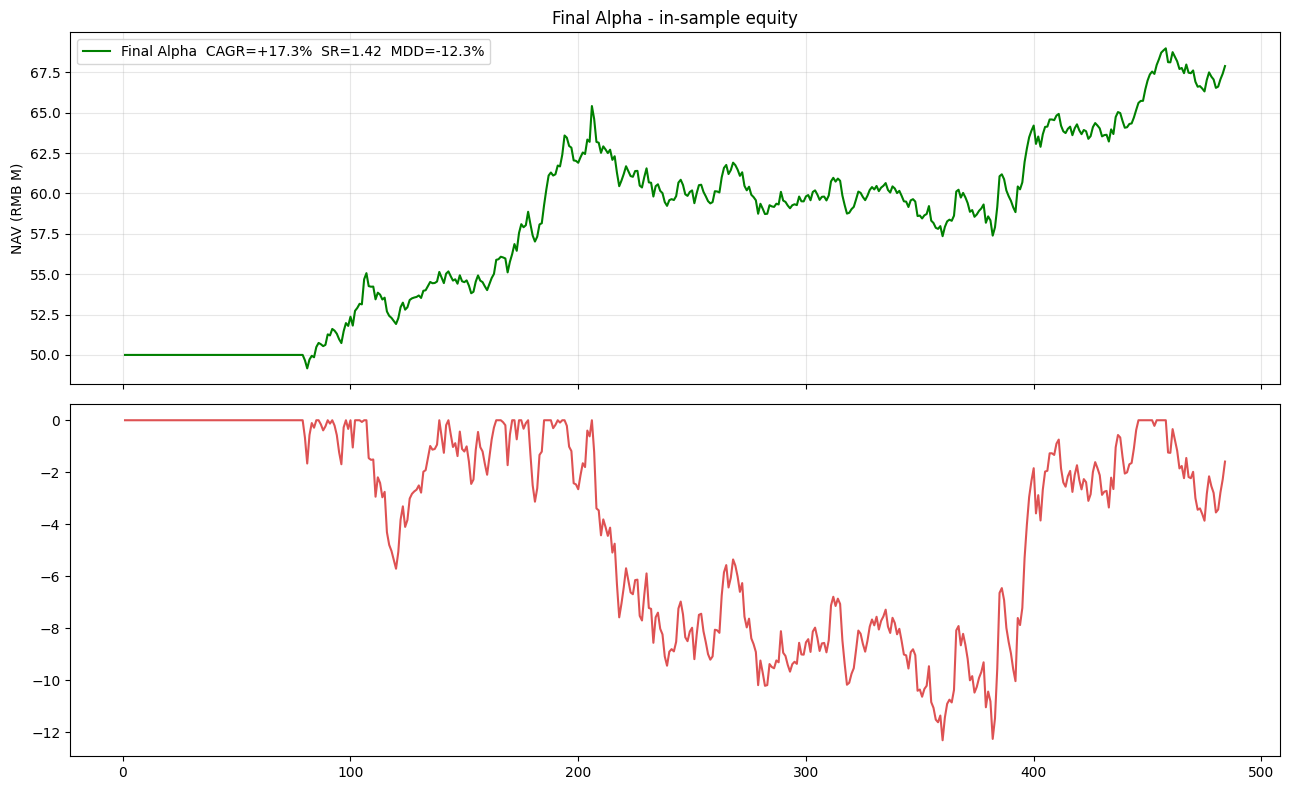

In [14]:
fig,ax=plt.subplots(2,1,figsize=(13,8),sharex=True)
nv=nav['nav'].values
ax[0].plot(nav['day'], nv/1e6, color='green', label=f'Final Alpha  CAGR={m["CAGR"]:+.1%}  SR={m["Sharpe"]:.2f}  MDD={m["MaxDD"]:.1%}')
ax[0].set_ylabel('NAV (RMB M)'); ax[0].set_title('Final Alpha - in-sample equity'); ax[0].legend(); ax[0].grid(alpha=0.3)
peak=np.maximum.accumulate(nv); ax[1].plot(nav['day'], (nv/peak-1)*100, color='C3', alpha=0.8)
plt.tight_layout()

# export the figure
import os; os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig1_is_equity.png', dpi=150, bbox_inches='tight')
plt.show()